# Example Use Case

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import os
import umap
import numpy as np
import networkx as nx
import anndata as ad
import scanpy as sc
from sctram.generate.synthetic.simple import AdjacencyMatrixGenerator, CentroidCalculator, SpacePopulator

In [4]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

## Smaller Example

In [5]:
# Define the desired structures with associations
structures = [
    {'name': '3', 'type': 'linear', 'num_nodes': 6, 'associated': ['7']},
    {'name': '7', 'type': 'grid', 'num_nodes': 12, 'associated': [], 'rows': 4, 'cols': 3, }
]

In [6]:
total_nodes = 18 

adjacency_matrix, labels = AdjacencyMatrixGenerator.generate_complex_adjacency_matrix_with_labels(
    total_nodes=total_nodes,
    structures=structures,
    connected_weight_range=(0.5, 0.8),
    associated_weight_range=(0.2, 0.4),
    unconnected_weight_range=(0.01, 0.1),
    inter_structure_connection_prob=0.05,
    seed=42
)

print(adjacency_matrix[0, :5])

[0.         0.78645958 0.07587945 0.06387926 0.02404168]


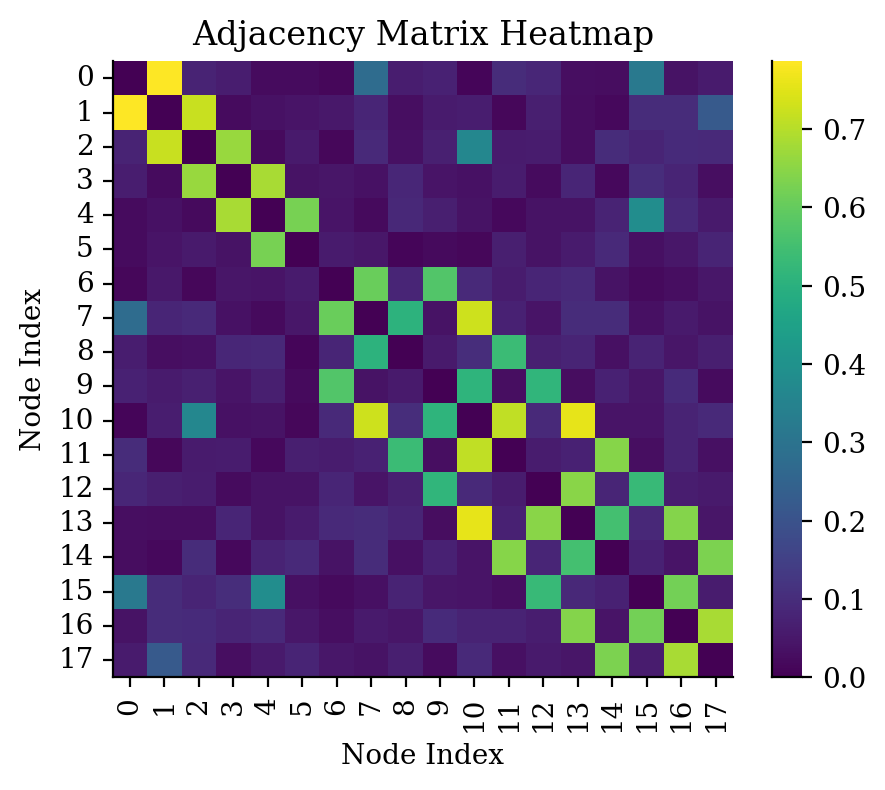

In [7]:
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix, cmap='viridis')
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
sns.despine()
plt.show()

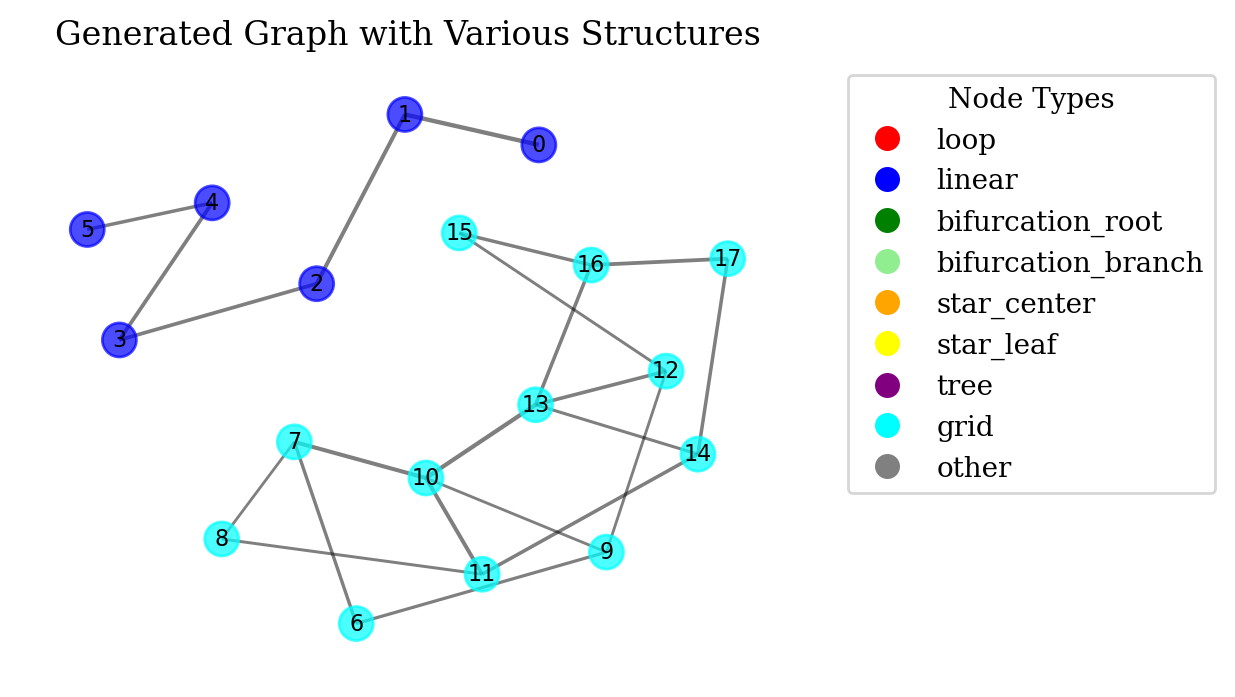

In [8]:
import matplotlib.pyplot as plt

# Create the graph using NetworkX
G = nx.from_numpy_array(adjacency_matrix)

# Assign colors based on labels
label_color_map = {
    'loop': 'red',
    'linear': 'blue',
    'bifurcation_root': 'green',
    'bifurcation_branch': 'lightgreen',
    'star_center': 'orange',
    'star_leaf': 'yellow',
    'tree': 'purple',
    'grid': 'cyan',
    'other': 'grey'
}
colors = [label_color_map.get(label, 'black') for label in labels]

# Draw the graph
plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G, seed=42)  # Positions for all nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=150, alpha=0.7)
# To reflect similarity scores in edge widths, map similarity to line width
edges = G.edges()
weights = [adjacency_matrix[u][v] for u, v in edges]

# Filter edges based on weight threshold
threshold = 0.5
edges_above_threshold = [(u, v) for u, v in edges if adjacency_matrix[u][v] > threshold]
weights_above_threshold = [adjacency_matrix[u][v] for u, v in edges_above_threshold]

nx.draw_networkx_edges(G, pos, edgelist=edges_above_threshold, alpha=0.5, width=[w * 2 for w in weights_above_threshold])
nx.draw_networkx_labels(G, pos, labels={i: i for i in G.nodes()}, font_size=8)

# Create a legend for the colors
patch_list = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                         markersize=10, markerfacecolor=color) for label, color in label_color_map.items()]
plt.legend(handles=patch_list, loc='upper left', bbox_to_anchor=(1.05, 1), title="Node Types")

plt.title("Generated Graph with Various Structures")
plt.axis('off')
plt.show()

In [9]:
# Initialize the CentroidCalculator with the desired method
centroid_calculator = CentroidCalculator(
    centroid_method='mds',    # Choose from 'mds', 'spectral', 'isomap', 'kernel_pca', 'laplacian'
    adjacency_matrix=adjacency_matrix,
    num_features=20,                # Number of dimensions for the reduced space
    random_state=42
)

# Compute the centroids
centroids = centroid_calculator.get()
centroids.shape

(18, 20)

/var/folders/y7/7c17s0l57szdjc1cdc9dmnpm0000gn/T/ipykernel_39446/270911268.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=50, cmap='Spectral')


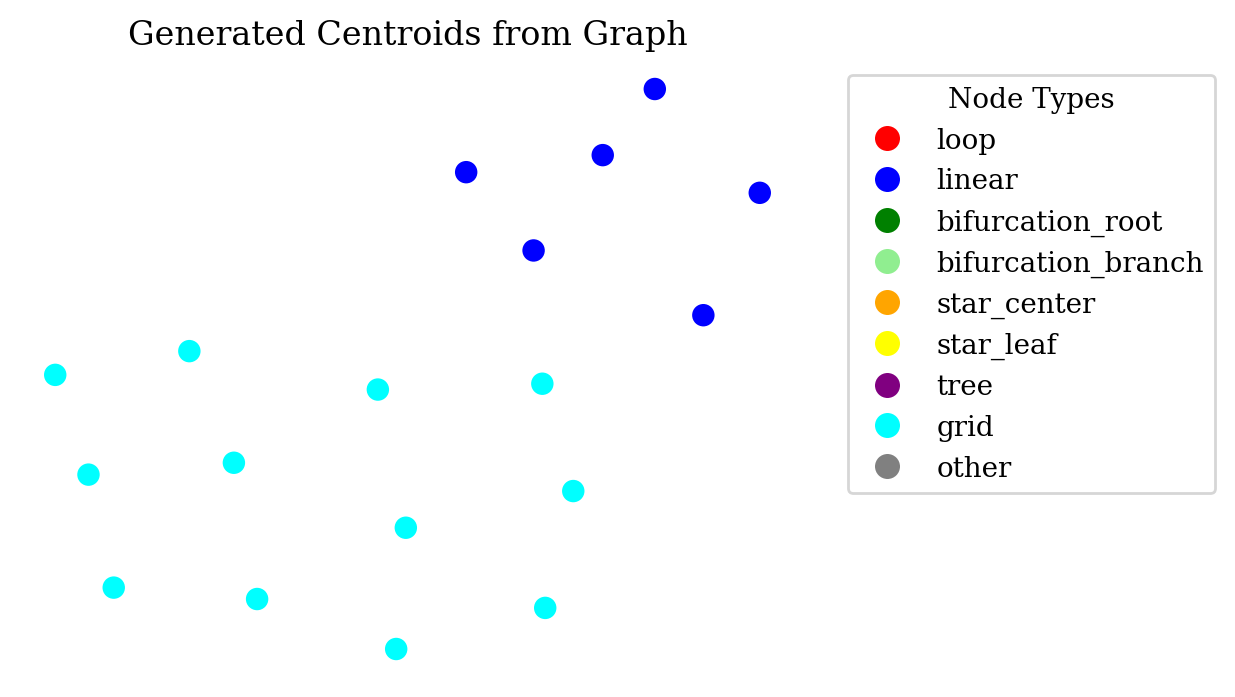

In [10]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, n_jobs=1)
embedding = reducer.fit_transform(centroids)

plt.figure(figsize=(5, 4))
plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=50, cmap='Spectral')
plt.axis('off')

patch_list = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                         markersize=10, markerfacecolor=color) for label, color in label_color_map.items()]
plt.legend(handles=patch_list, loc='upper left', bbox_to_anchor=(1.05, 1), title="Node Types")
plt.title("Generated Centroids from Graph")
plt.show()

In [11]:
# Instantiate the DataGenerator with z_score
data_generator = SpacePopulator(
    centroids=centroids,
    adjacency_matrix=adjacency_matrix,
    labels=np.array(labels),
    total_points=20000,
    centroid_proportion=0.2,
    cluster_distribution = 'gaussian',
    cluster_distribution_z = 2,
    edge_distribution = 'reverse_gaussian',
    edge_noise_distribution_z = 2,
    edge_distribution_params = {'sigma': 0.15},
    random_state=42
)
data_points, data_points_metadata = data_generator.generate_data()

data_points.shape, data_points_metadata.shape

((20018, 20), (20018, 7))

In [12]:
data_points_metadata

,type,node_index,node_label,edge_indices,edge_labels,node_index_extended,node_label_extended
0,centroids,0.0,linear,None,None,0,linear
1,centroids,1.0,linear,None,None,1,linear
2,centroids,2.0,linear,None,None,2,linear
3,centroids,3.0,linear,None,None,3,linear
4,centroids,4.0,linear,None,None,4,linear
...,...,...,...,...,...,...,...
20013,edge,NaN,NaN,16-17,grid-grid,17,grid
20014,edge,NaN,NaN,16-17,grid-grid,16,grid
20015,edge,NaN,NaN,16-17,grid-grid,16,grid
20016,edge,NaN,NaN,16-17,grid-grid,17,grid


In [13]:
adata = ad.AnnData(X=data_points, obs=data_points_metadata)
adata.obs["node_index"] = adata.obs["node_index"].astype(str)
adata.obs.loc[adata.obs["node_index"] == "None", "node_index"] = np.nan
adata.obs["node_index_extended"] = adata.obs["node_index_extended"].astype(str)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/Users/kemalinecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


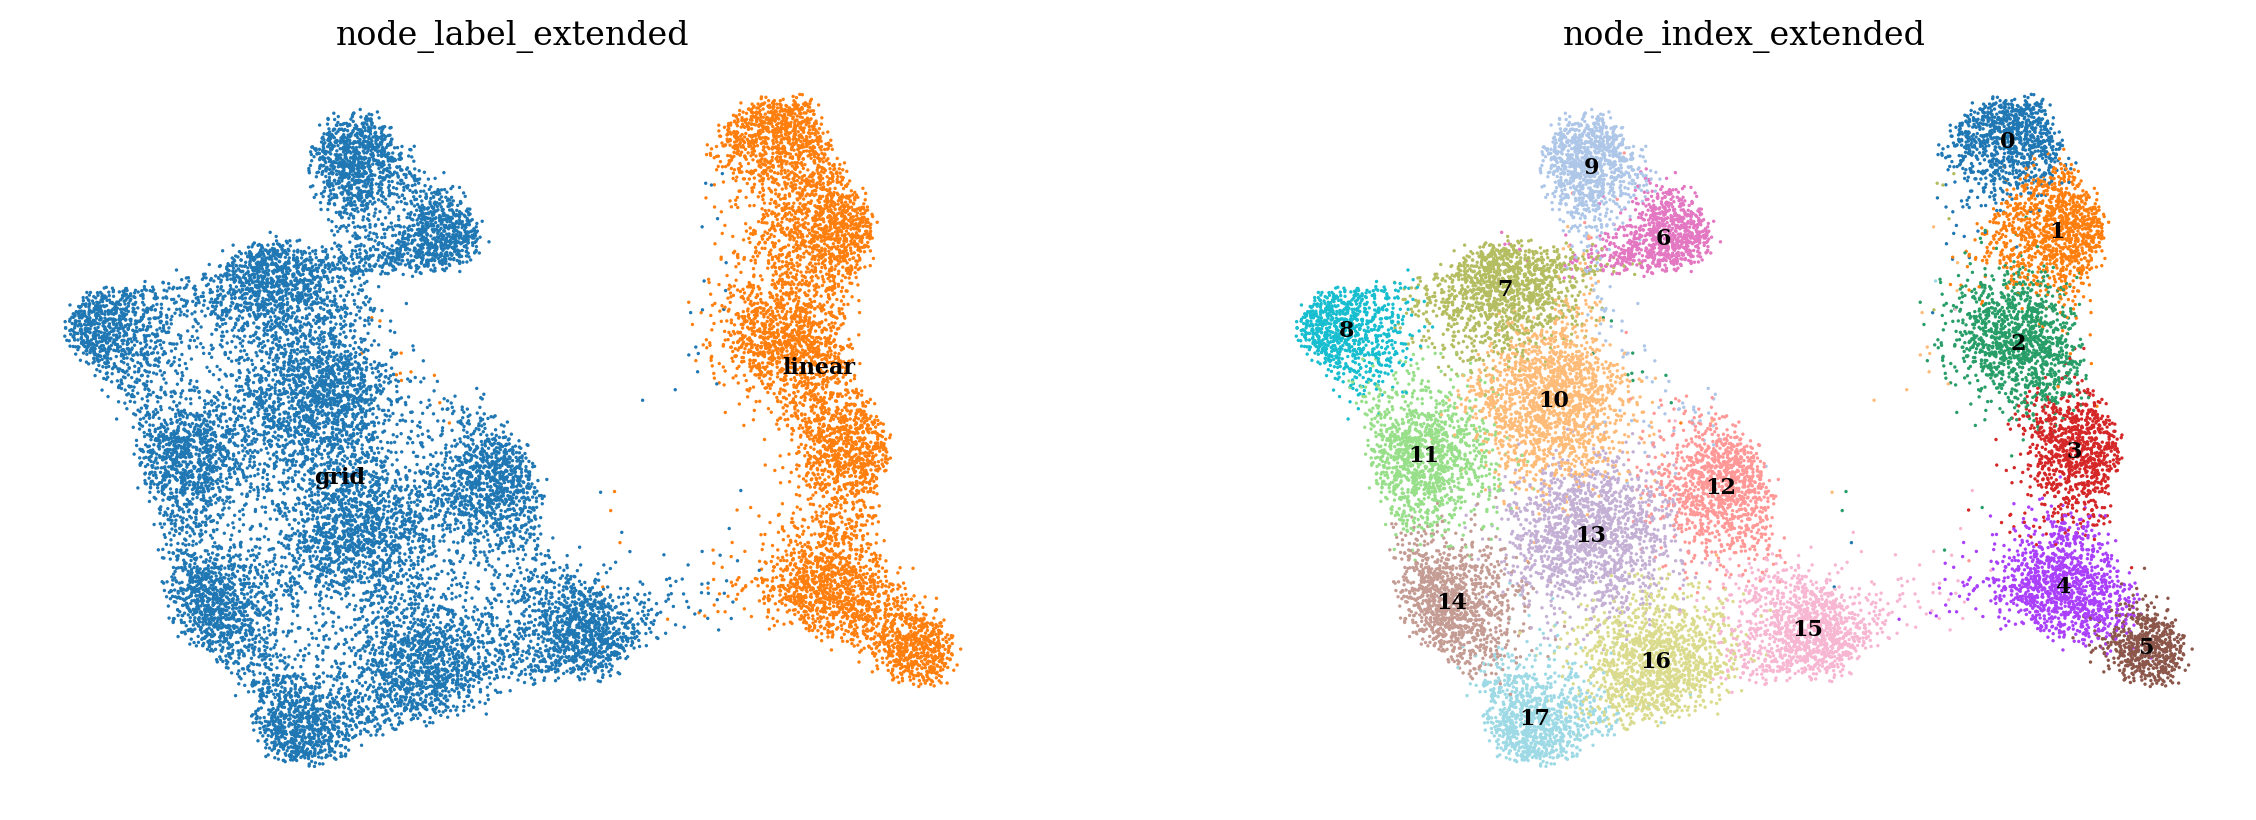

In [14]:
sc.pl.umap(adata, color=["node_label_extended", "node_index_extended"], legend_loc="on data", legend_fontsize=8, frameon=False)

In [15]:
sc.tl.paga(adata, groups="node_index_extended")

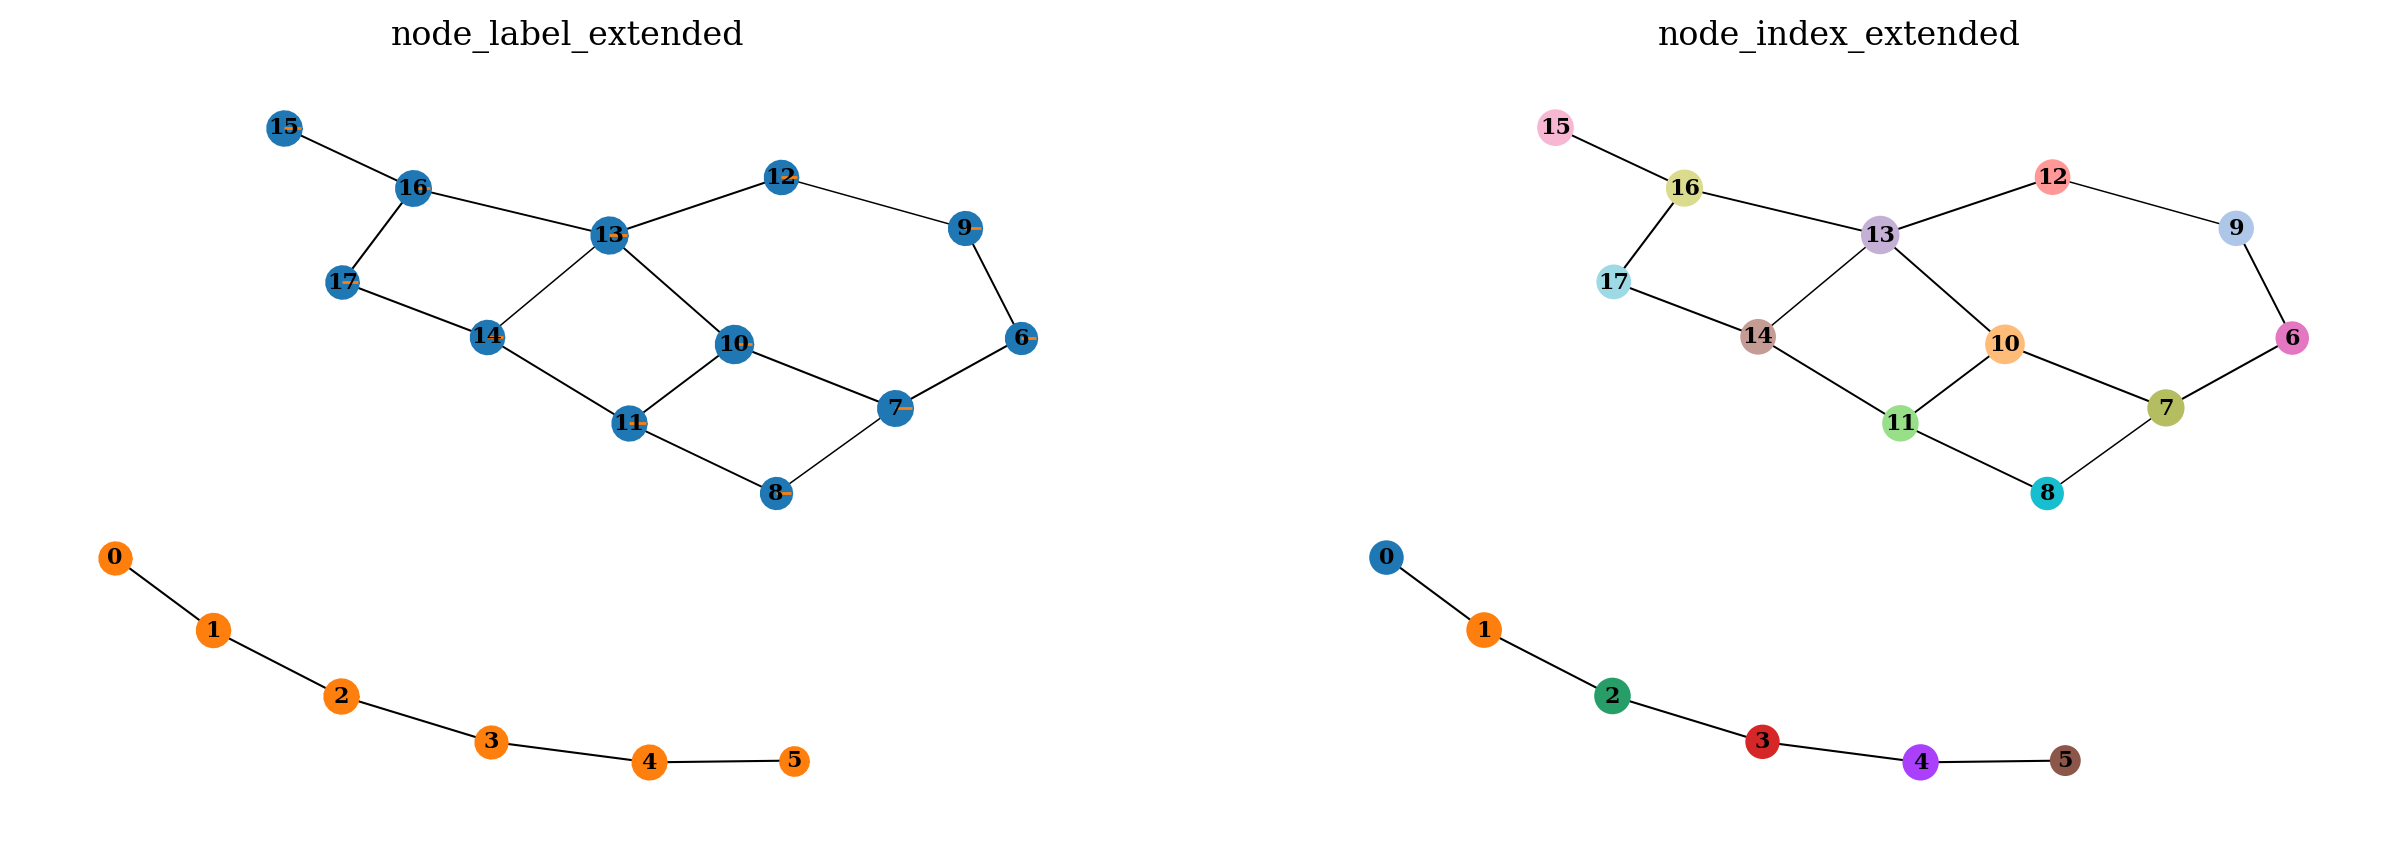

In [16]:
sc.pl.paga(adata, color=['node_label_extended', 'node_index_extended'], 
           threshold=0.5, node_size_scale=1, edge_width_scale=0.1, fontsize=8, frameon=False
)

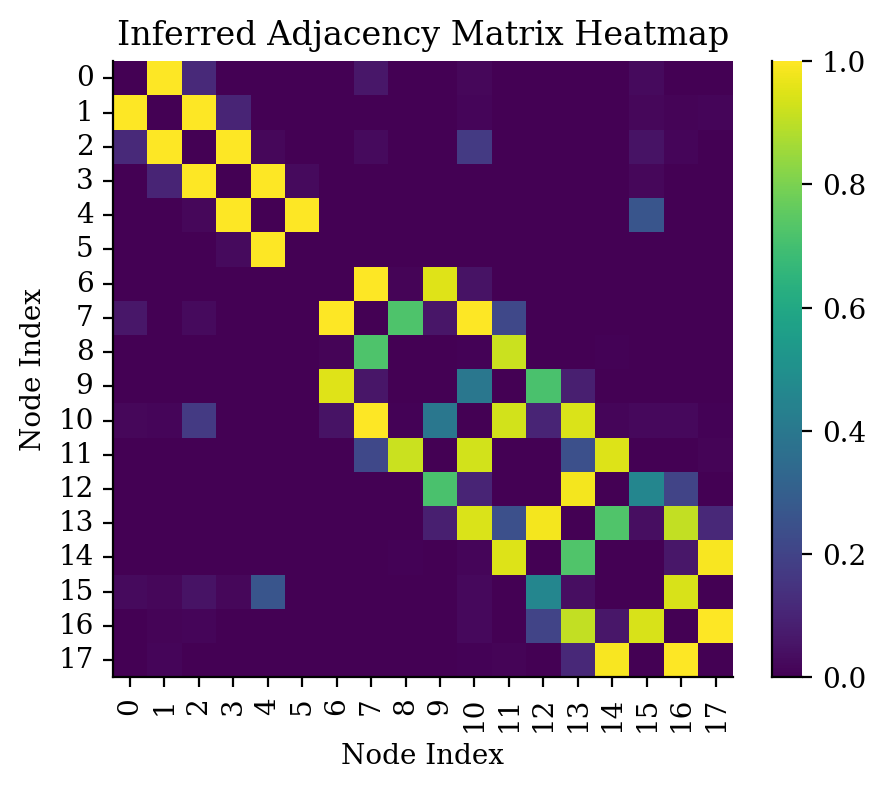

In [17]:
inferred_adjacency_matrix = adata.uns['paga']["connectivities"].toarray()
plt.figure(figsize=(5, 4))
sns.heatmap(inferred_adjacency_matrix, cmap='viridis')
plt.title("Inferred Adjacency Matrix Heatmap")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
sns.despine()
plt.show()

## Larger Example

In [18]:
# Define the desired structures with associations
structures = [
    {'name': '1', 'type': 'loop', 'num_nodes': 3, 'associated': ['6']},
    {'name': '2', 'type': 'loop', 'num_nodes': 5, 'associated': ['7']},
    {'name': '3', 'type': 'linear', 'num_nodes': 6, 'associated': ['7']},
    {'name': '4', 'type': 'bifurcation', 'num_nodes': 12, 'associated': ['7'], 'branches': 3},
    {'name': '5', 'type': 'star', 'num_nodes': 6, 'associated': ['7']},
    {'name': '6', 'type': 'tree', 'num_nodes': 15, 'associated': [], 'depth': 3},
    {'name': '7', 'type': 'grid', 'num_nodes': 20, 'associated': [], 'rows': 5, 'cols': 4}
]

In [19]:
total_nodes = 67 

adjacency_matrix, labels = AdjacencyMatrixGenerator.generate_complex_adjacency_matrix_with_labels(
    total_nodes=total_nodes,
    structures=structures,
    connected_weight_range=(0.5, 0.8),
    associated_weight_range=(0.2, 0.4),
    unconnected_weight_range=(0.01, 0.1),
    inter_structure_connection_prob=0.05,
    seed=42
)

print(adjacency_matrix[0, :5])

[0.         0.66916788 0.57834873 0.06387926 0.02404168]


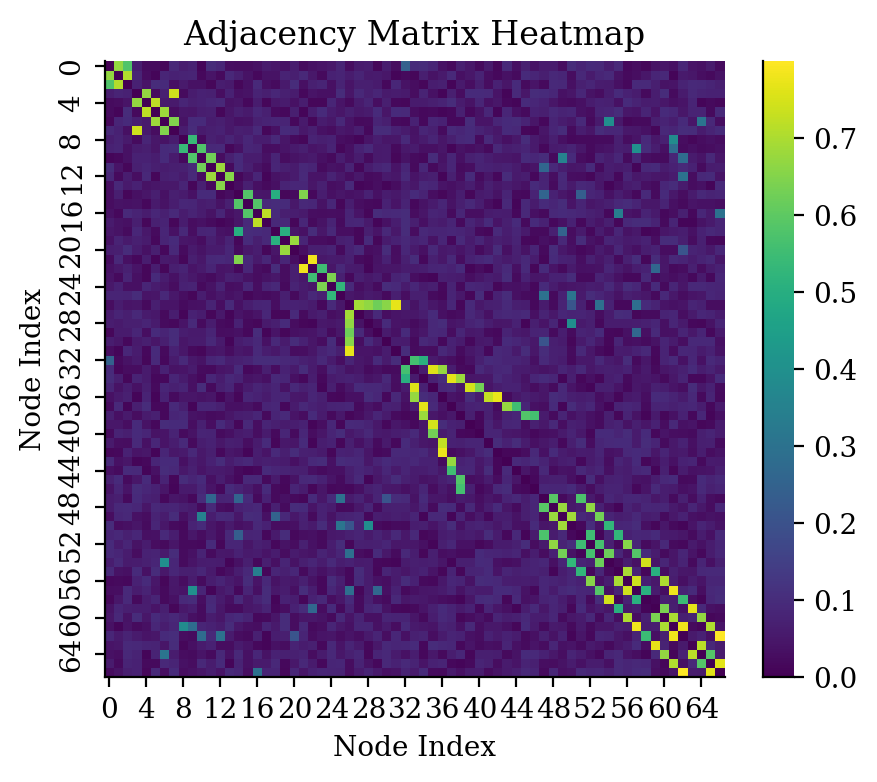

In [20]:
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix, cmap='viridis')
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
sns.despine()
plt.show()

In [21]:
# Initialize the CentroidCalculator with the desired method
centroid_calculator = CentroidCalculator(
    centroid_method='mds',    # Choose from 'mds', 'spectral', 'isomap', 'kernel_pca', 'laplacian'
    adjacency_matrix=adjacency_matrix,
    num_features=20,                # Number of dimensions for the reduced space
    random_state=42
)

# Compute the centroids
centroids = centroid_calculator.get()
centroids.shape

(67, 20)

In [22]:
# Instantiate the DataGenerator with z_score
data_generator = SpacePopulator(
    centroids=centroids,
    adjacency_matrix=adjacency_matrix,
    labels=np.array(labels),
    total_points=20000,
    centroid_proportion=0.2,
    cluster_distribution = 'gaussian',
    cluster_distribution_z = 2,
    edge_distribution = 'reverse_gaussian',
    edge_noise_distribution_z = 2,
    edge_distribution_params = {'sigma': 0.65},
    random_state=42
)
data_points, data_points_metadata = data_generator.generate_data()

data_points.shape, data_points_metadata.shape

((20067, 20), (20067, 7))

In [23]:
adata = ad.AnnData(X=data_points, obs=data_points_metadata)
adata.obs["node_index"] = adata.obs["node_index"].astype(str)
adata.obs.loc[adata.obs["node_index"] == "None", "node_index"] = np.nan
adata.obs["node_index_extended"] = adata.obs["node_index_extended"].astype(str)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/Users/kemalinecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


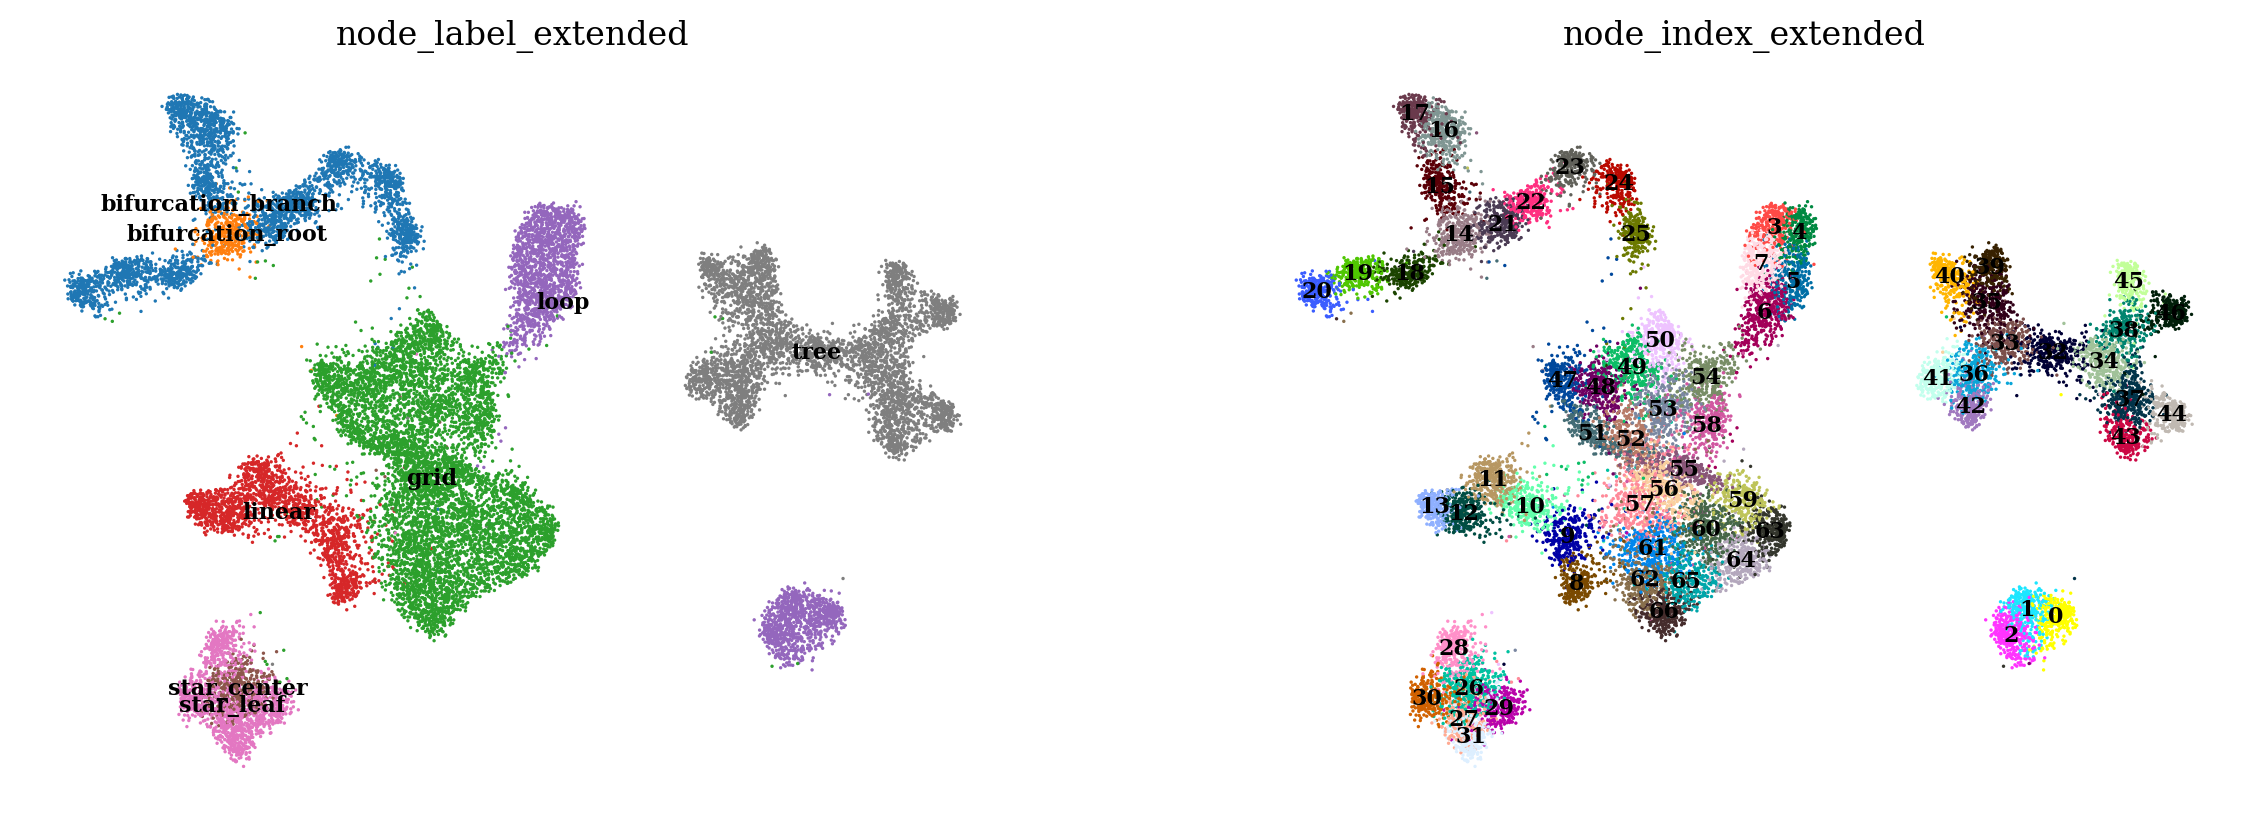

In [24]:
sc.pl.umap(adata, color=["node_label_extended", "node_index_extended"], legend_loc="on data", legend_fontsize=8, frameon=False)

In [25]:
sc.tl.paga(adata, groups="node_index_extended")

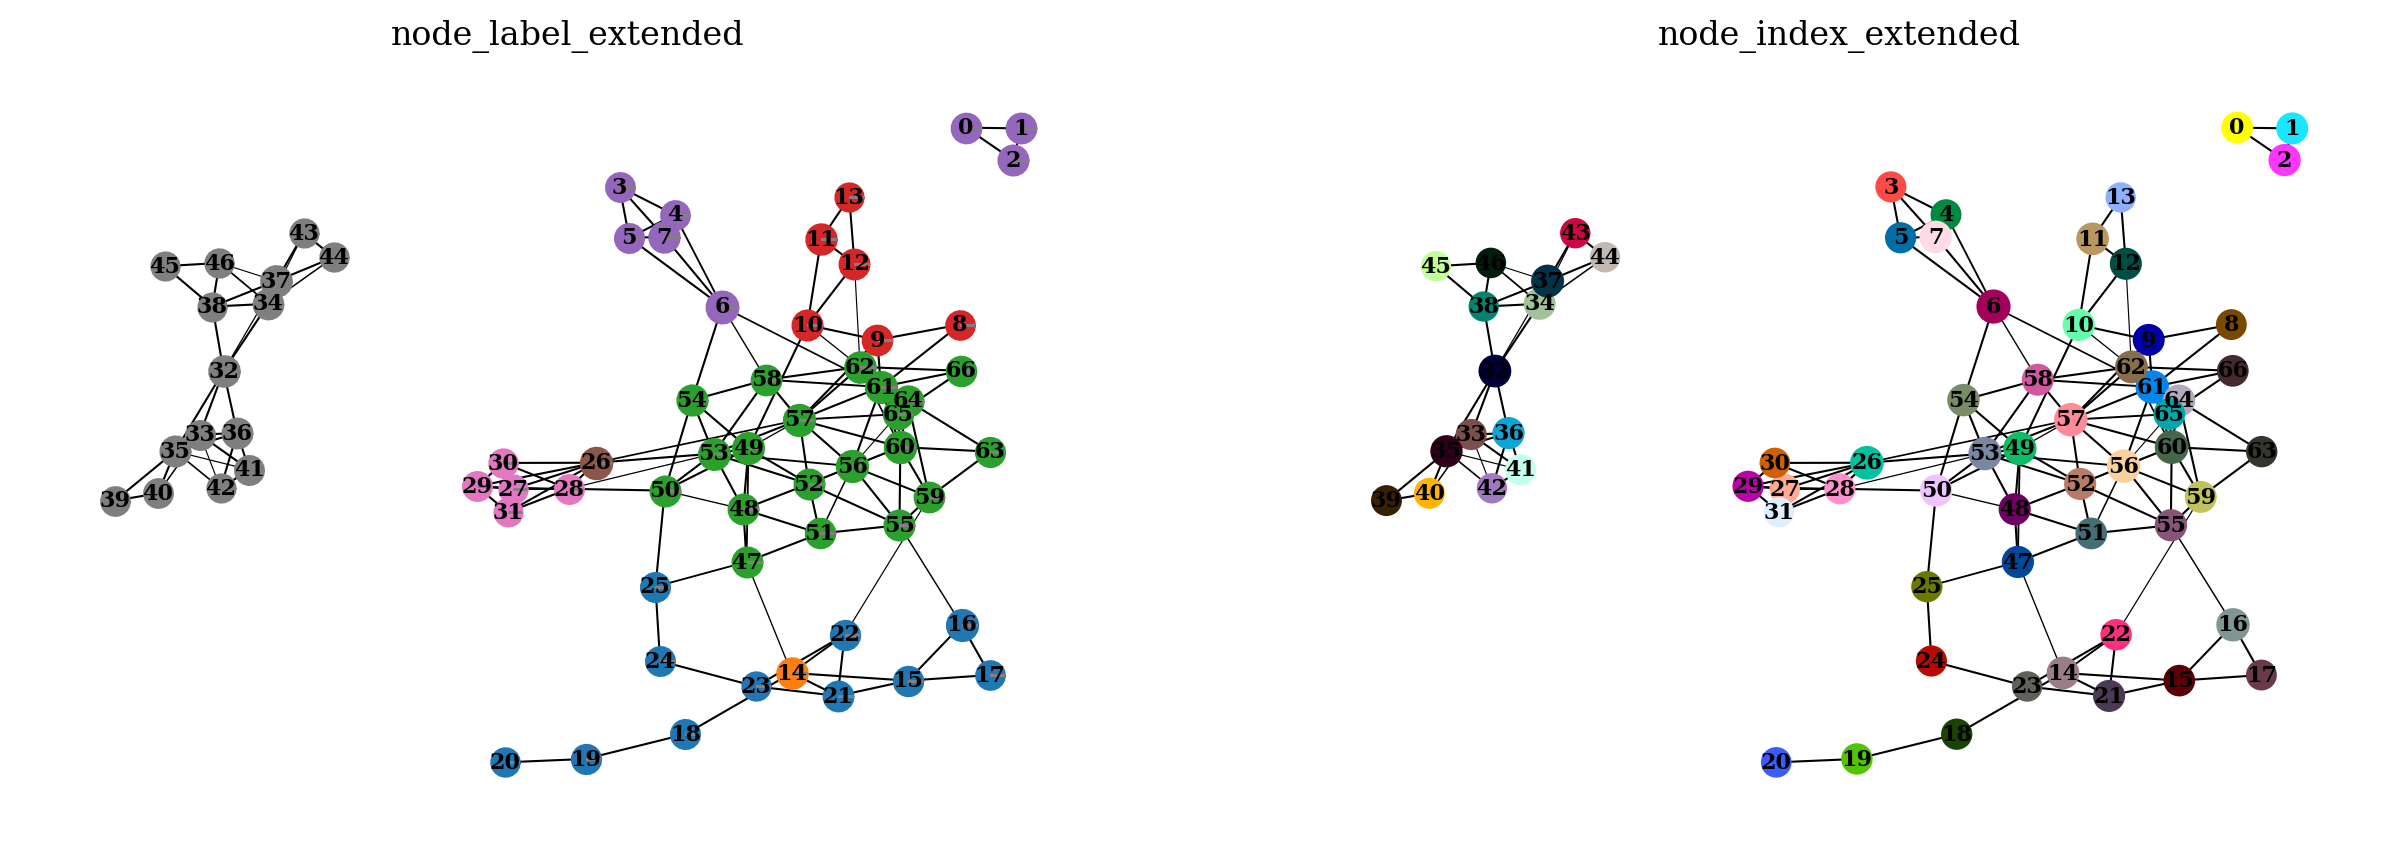

In [26]:
sc.pl.paga(adata, color=['node_label_extended', 'node_index_extended'], 
           threshold=0.5, node_size_scale=1, edge_width_scale=0.1, fontsize=8, frameon=False
)

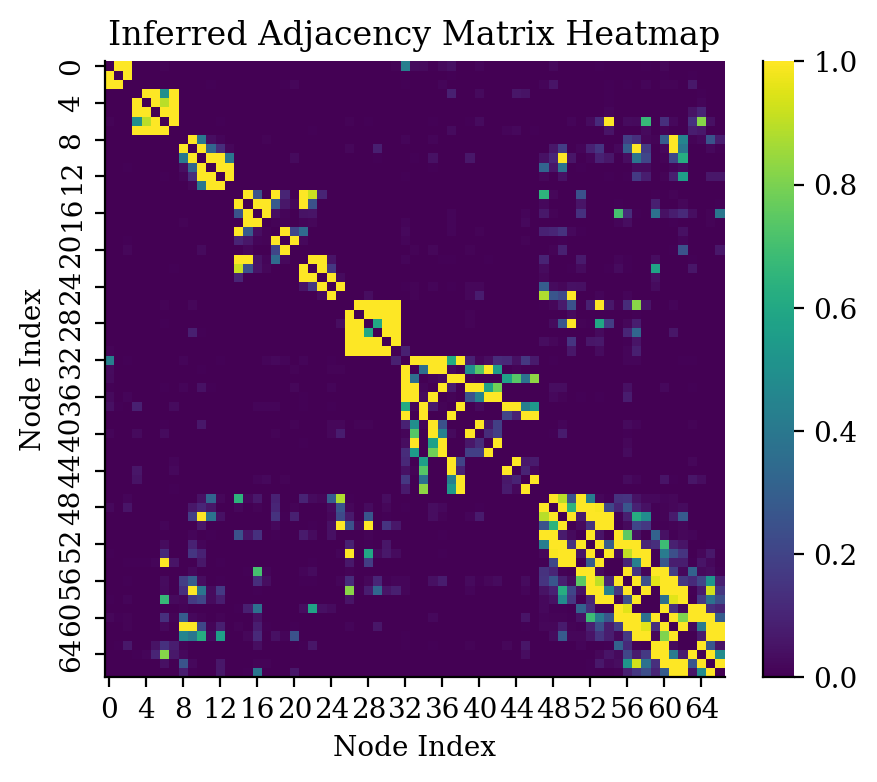

In [27]:
inferred_adjacency_matrix = adata.uns['paga']["connectivities"].toarray()
plt.figure(figsize=(5, 4))
sns.heatmap(inferred_adjacency_matrix, cmap='viridis')
plt.title("Inferred Adjacency Matrix Heatmap")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
sns.despine()
plt.show()

## Larger Example - No weak association

[0.         0.66916788 0.57834873 0.06387926 0.02404168]


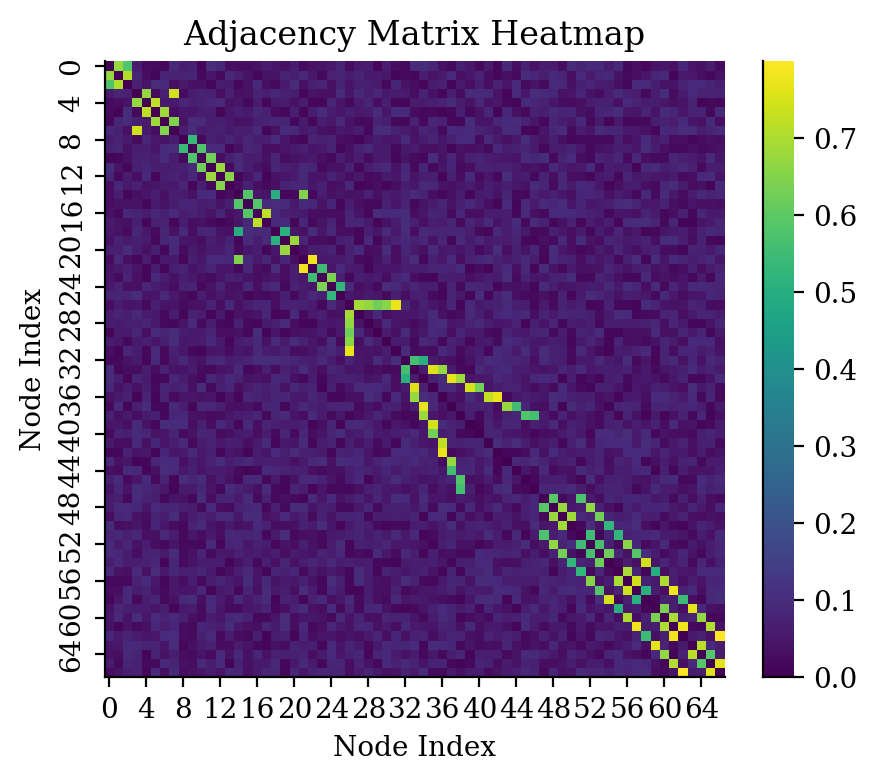

/Users/kemalinecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


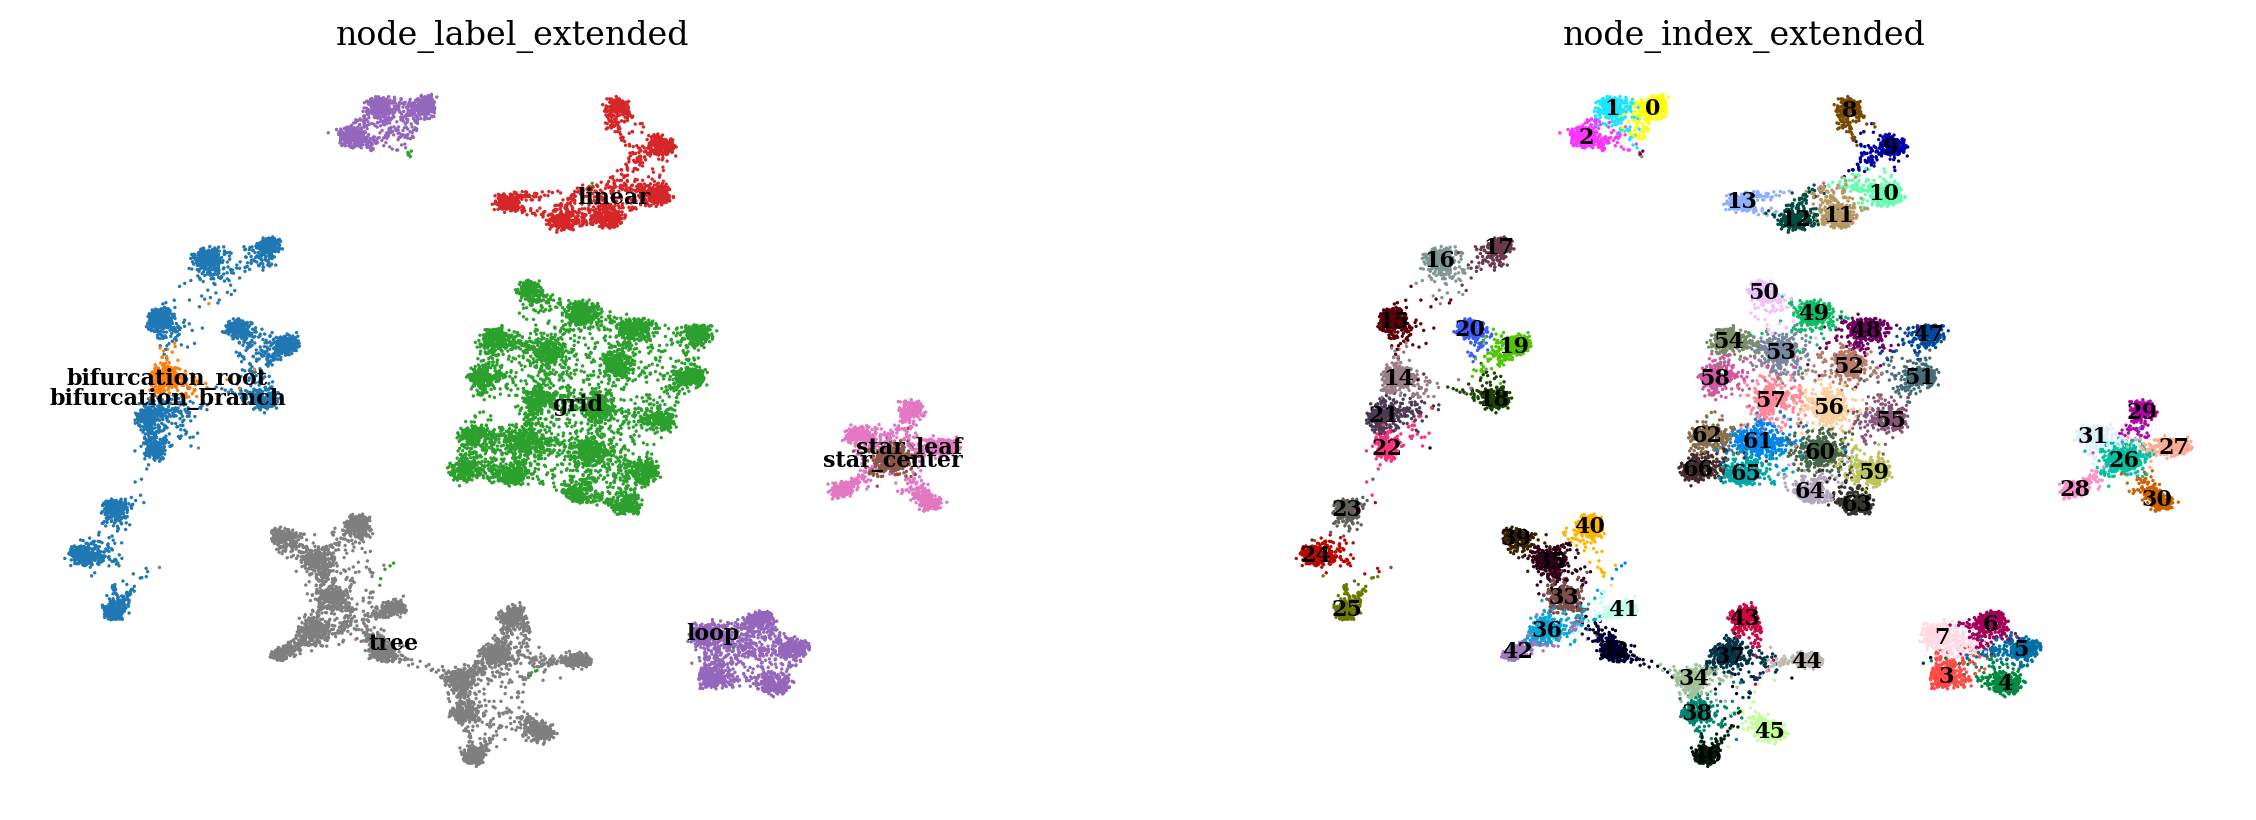

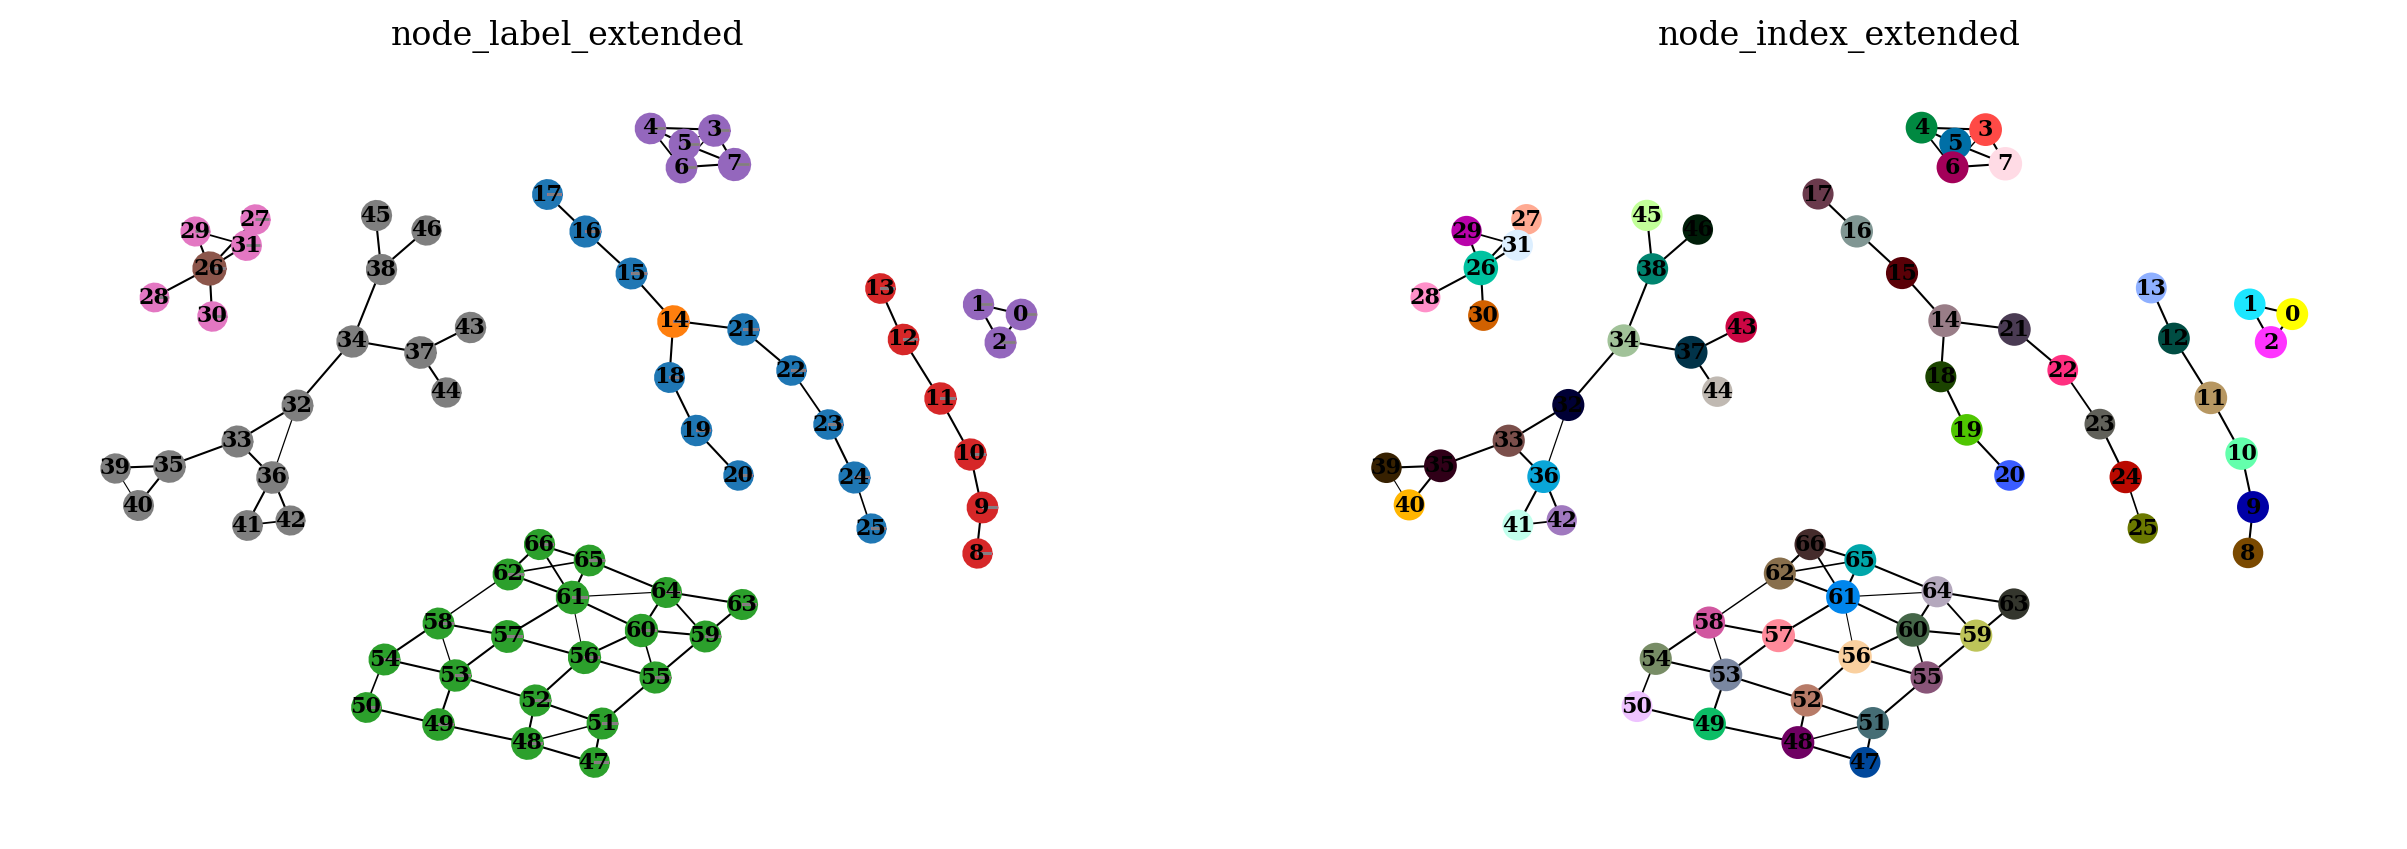

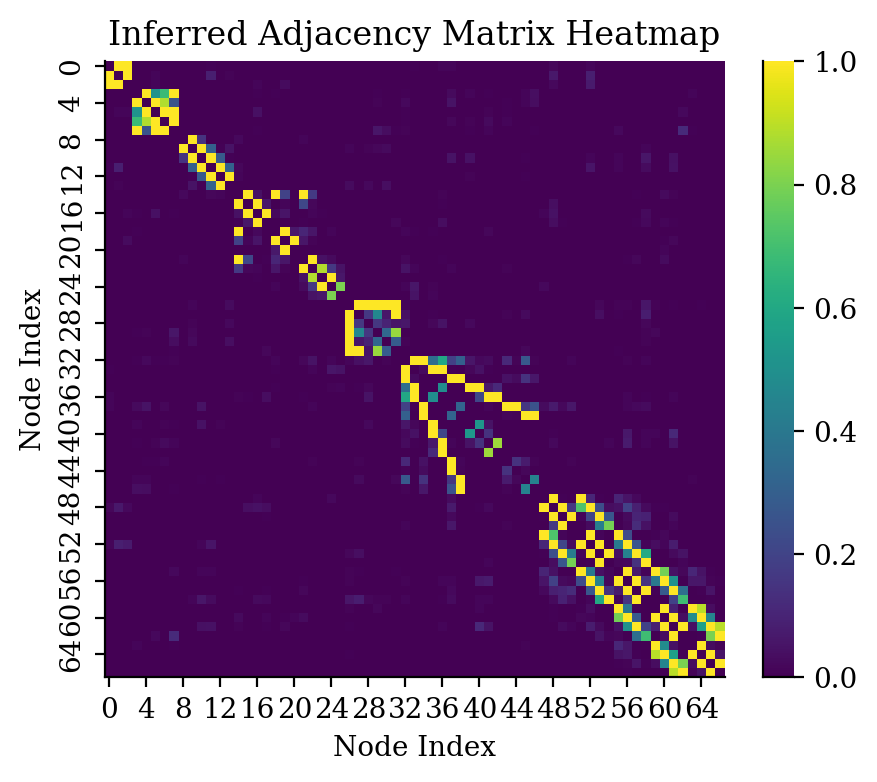

In [28]:
## Larger Example
# Define the desired structures with associations
structures = [
    {'name': '1', 'type': 'loop', 'num_nodes': 3, 'associated': ['6']},
    {'name': '2', 'type': 'loop', 'num_nodes': 5, 'associated': ['7']},
    {'name': '3', 'type': 'linear', 'num_nodes': 6, 'associated': ['7']},
    {'name': '4', 'type': 'bifurcation', 'num_nodes': 12, 'associated': ['7'], 'branches': 3},
    {'name': '5', 'type': 'star', 'num_nodes': 6, 'associated': ['7']},
    {'name': '6', 'type': 'tree', 'num_nodes': 15, 'associated': [], 'depth': 3},
    {'name': '7', 'type': 'grid', 'num_nodes': 20, 'associated': [], 'rows': 5, 'cols': 4}
]
total_nodes = 67 

adjacency_matrix, labels = AdjacencyMatrixGenerator.generate_complex_adjacency_matrix_with_labels(
    total_nodes=total_nodes,
    structures=structures,
    connected_weight_range=(0.5, 0.8),
    associated_weight_range=(0.2, 0.4),
    unconnected_weight_range=(0.01, 0.1),
    inter_structure_connection_prob=0.0,
    seed=42
)

print(adjacency_matrix[0, :5])
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix, cmap='viridis')
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
sns.despine()
plt.show()
# Initialize the CentroidCalculator with the desired method
centroid_calculator = CentroidCalculator(
    centroid_method='mds',    # Choose from 'mds', 'spectral', 'isomap', 'kernel_pca', 'laplacian'
    adjacency_matrix=adjacency_matrix,
    num_features=20,                # Number of dimensions for the reduced space
    random_state=42
)

# Compute the centroids
centroids = centroid_calculator.get()
centroids.shape
# Instantiate the DataGenerator with z_score
data_generator = SpacePopulator(
    centroids=centroids,
    adjacency_matrix=adjacency_matrix,
    labels=np.array(labels),
    total_points=20000,
    centroid_proportion=0.2,
    cluster_distribution = 'gaussian',
    cluster_distribution_z = 2,
    edge_distribution = 'reverse_gaussian',
    edge_noise_distribution_z = 2,
    edge_distribution_params = {'sigma': 0.65},
    random_state=42
)
data_points, data_points_metadata = data_generator.generate_data()

data_points.shape, data_points_metadata.shape
adata = ad.AnnData(X=data_points, obs=data_points_metadata)
adata.obs["node_index"] = adata.obs["node_index"].astype(str)
adata.obs.loc[adata.obs["node_index"] == "None", "node_index"] = np.nan
adata.obs["node_index_extended"] = adata.obs["node_index_extended"].astype(str)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["node_label_extended", "node_index_extended"], legend_loc="on data", legend_fontsize=8, frameon=False)
sc.tl.paga(adata, groups="node_index_extended")
sc.pl.paga(adata, color=['node_label_extended', 'node_index_extended'], 
           threshold=0.5, node_size_scale=1, edge_width_scale=0.1, fontsize=8, frameon=False
)
inferred_adjacency_matrix = adata.uns['paga']["connectivities"].toarray()
plt.figure(figsize=(5, 4))
sns.heatmap(inferred_adjacency_matrix, cmap='viridis')
plt.title("Inferred Adjacency Matrix Heatmap")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
sns.despine()
plt.show()


## Random Adjacency Matrix

In [29]:
# Generate a complex adjacency matrix
adjacency_matrix = AdjacencyMatrixGenerator.generate_random_adjacency_matrix(
    graph_type='watts_strogatz',
    num_nodes=50,
    k=20,   # Each node is connected to 10 nearest neighbors
    p=0.1,  # Rewiring probability
    weighted= True,
    seed=42
)

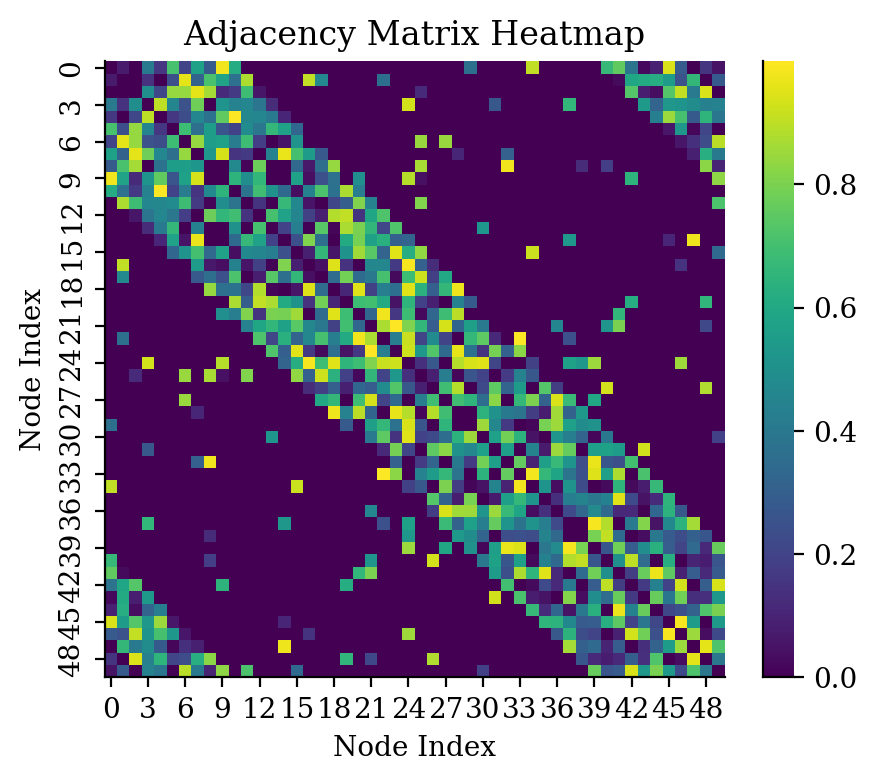

In [30]:
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix, cmap='viridis')
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
sns.despine()
plt.show()